# Local Train

Goal:

- Train a YOLO model to detect license plates.
- Use notebook.
- Get a working training pipeline run
  - Accuracy is not priority.


## Environment


In [1]:
import sys
from pathlib import Path

import torch
import ultralytics

# Repo root
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# raw data
RAW = ROOT / "data" / "raw"
# split data
PROCESSED = ROOT / "data" / "processed"

# print versions
print("python     ", sys.version.split()[0])
print("torch      ", torch.__version__)
print("ultralytics", ultralytics.__version__)
print("cuda       ", torch.cuda.is_available())

WARNING ⚠️ user config directory '/workspace/.ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
python      3.12.13
torch       2.13.0+cu130
ultralytics 8.4.116
cuda        False


## Data summary

Inspect the raw dataset before training. 

In [2]:
# load helper
from src.data_loader import summarize

stats = summarize(RAW)
for key, value in stats.items():
    print(f"{key:22} {value}")  # Data summary

pairs                  556
orphan_images          []
orphan_labels          []
boxes_total            574
boxes_per_image_min    1
boxes_per_image_max    3
boxes_per_image_mean   1.03
images_without_boxes   0
class_counts           {'0': 574}
suffixes               {'.jpeg': 543, '.png': 13}
malformed              []


Visualize labels with images.


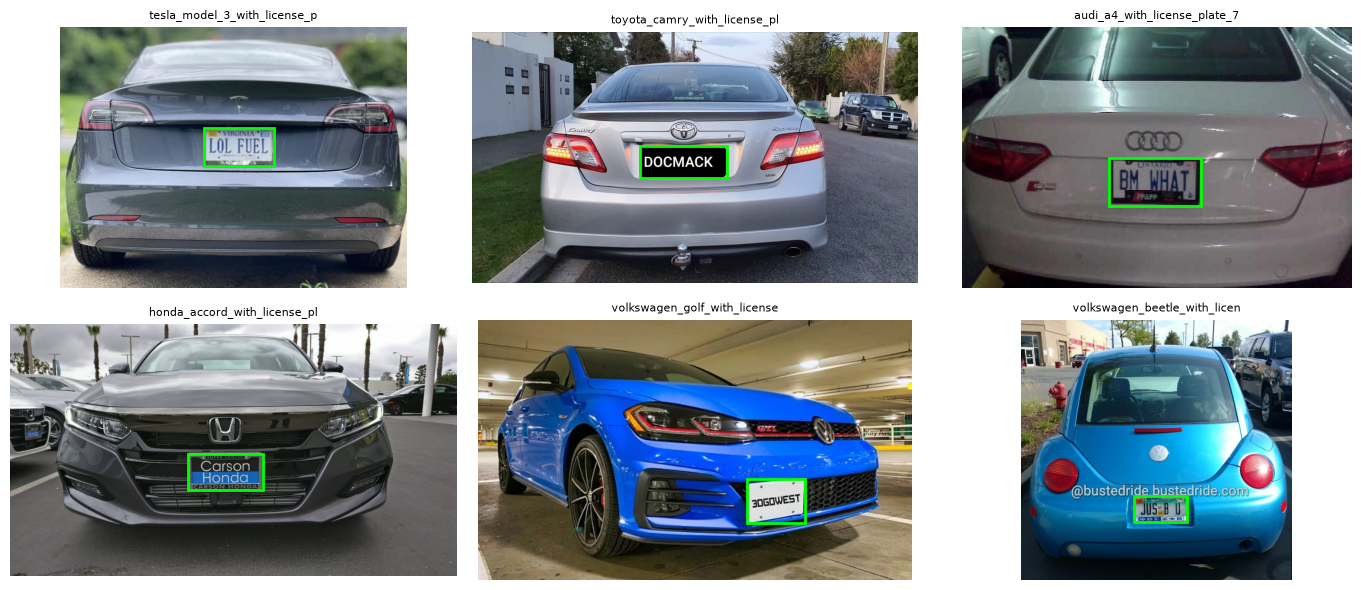

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data_loader import find_pairs


def show_sample(pairs, n=6, seed=0):
    """Draw label boxes on a few images to confirm the annotations line up."""
    import random

    sample = random.Random(seed).sample(pairs, n)
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for ax, (img_path, lbl_path) in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        ax.imshow(img)
        w, h = img.size
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            # YOLO stores normalised centre + size; matplotlib wants corners.
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h),
                    bw * w,
                    bh * h,
                    fill=False,
                    edgecolor="lime",
                    linewidth=2,
                )
            )
        ax.set_title(img_path.stem[:28], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


pairs, _, _ = find_pairs(RAW)
show_sample(pairs)

## Split

80/20 train/val, seeded so the split is reproducible.
`LIMIT` caps the number of pairs.


In [4]:
from src.data_loader import build_split, verify_split

# limit for fast smoke run; e.g. 200
# LIMIT = None  # unlimit
LIMIT = 200  # limit 200

# print split
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=0))
print(verify_split(PROCESSED))

{'train': 160, 'val': 40, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 160, 'val': 40}


## Dataset configuration file

Create dataset configuration file `classes.txt`.


In [5]:
from src.data_loader import write_data_yaml

names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)

print(data_yaml)
print(data_yaml.read_text())

/workspace/configs/data.yaml
path: /workspace/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Model configuration

Select and Load pretrained model

- `yolo11n`: the smallest variant, which matters on CPU.


In [6]:
from ultralytics.data.utils import check_det_dataset
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

# check dataset configuration files before training
checked = check_det_dataset(str(data_yaml))
print({k: checked[k] for k in ("nc", "names", "train", "val")})

{'nc': 1, 'names': {0: 'car_plate'}, 'train': '/workspace/data/processed/train/images', 'val': '/workspace/data/processed/val/images'}


### Training hyperparameters

Use training parameters file `configs/train.yaml`


In [7]:
import yaml

# read config file
train_cfg = yaml.safe_load((ROOT / "configs" / "train.yaml").read_text())
train_cfg

{'model': 'yolo11n.pt',
 'epochs': 10,
 'imgsz': 416,
 'batch': 8,
 'device': 'cpu',
 'workers': 4,
 'seed': 0,
 'project': 'runs',
 'name': 'local-train',
 'exist_ok': True}

## Train

Train YOLO model.


In [8]:
import time

cfg = dict(train_cfg)
model_weights = cfg.pop("model")
cfg["project"] = str(ROOT / cfg["project"])

# construct model class with parameters
model = YOLO(model_weights)

# log start time
start = time.time()

# run the training process, get performance results
results = model.train(data=str(data_yaml), **cfg)

# print elapsed time
print(f"\nelapsed: {time.time() - start:.0f}s")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Core 5 120U)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/configs/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=local-train, nbs=64, nms=False, opse

Print performance results


In [9]:
# print performance results dir
save_dir = Path(results.save_dir)
print(save_dir)

# Final-epoch metrics on the validation split.
for key in ("metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"):
    print(f"{key:24} {results.results_dict[key]:.4f}")

print()
# list model file with weights
for weight in sorted((save_dir / "weights").glob("*.pt")):
    print(f"{weight.name:10} {weight.stat().st_size / 1e6:.1f} MB")

/workspace/runs/local-train
metrics/precision(B)     0.9449
metrics/recall(B)        0.9070
metrics/mAP50(B)         0.9513
metrics/mAP50-95(B)      0.7321

best.pt    5.4 MB
last.pt    5.4 MB


## Validate the model

Built-in method used to validate and evaluate the performance of a trained model


In [10]:
# read model from path
best = YOLO(str(save_dir / "weights" / "best.pt"))

# evaluate the performance of a trained model
metrics = best.val(data=str(data_yaml), imgsz=416, batch=8, device="cpu", plots=False)

print(f"mAP50      {metrics.box.map50:.4f}")
print(f"mAP50-95   {metrics.box.map:.4f}")
print(f"precision  {metrics.box.mp:.4f}")
print(f"recall     {metrics.box.mr:.4f}")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Core 5 120U)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 4.1±1.1 ms, read: 24.9±13.3 MB/s, size: 214.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /workspace/data/processed/val/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 18.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9it/s 2.6s0.6s
                   all         40         43      0.942      0.907      0.949      0.732
Speed: 0.3ms preprocess, 31.5ms inference, 0.0ms loss, 3.6ms postprocess per image
mAP50      0.9494
mAP50-95   0.7321
precision  0.9423
recall     0.9070


### Predictions vs fact

- Green = label
- Red = prediction


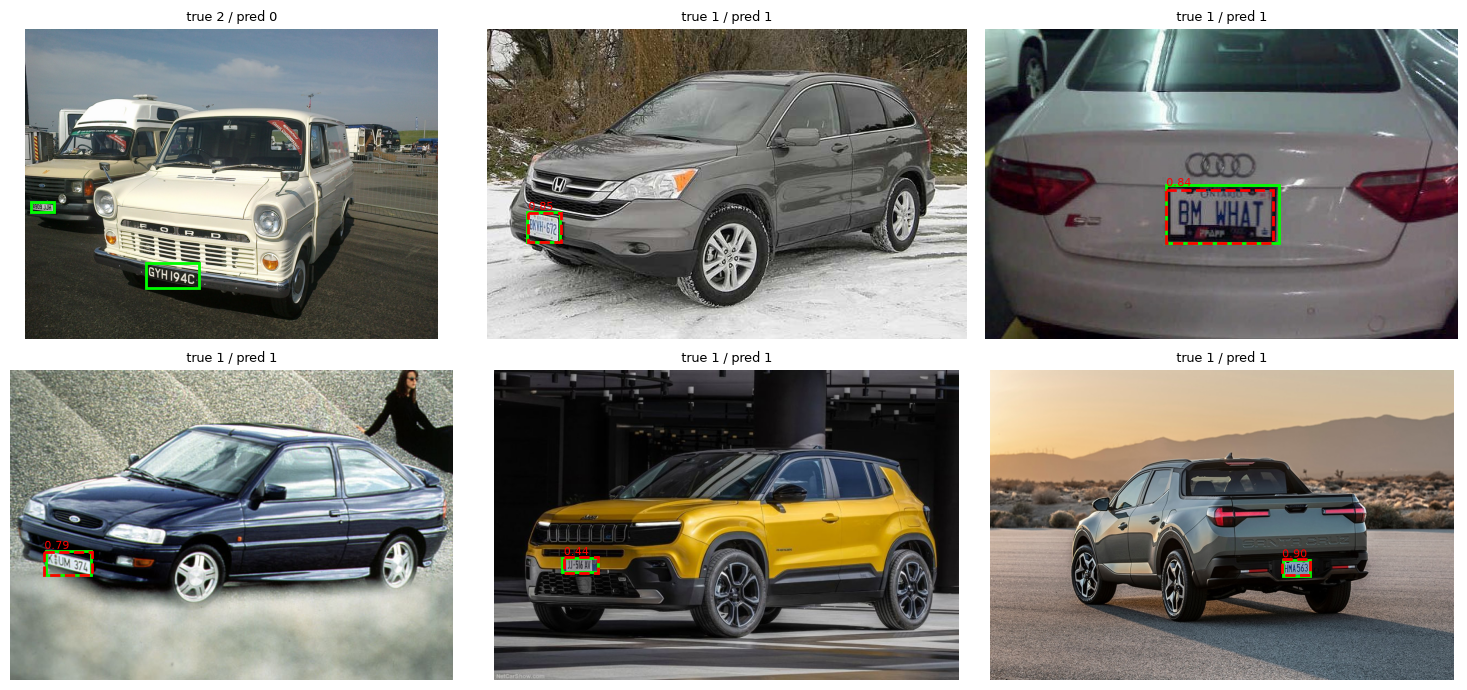

In [11]:
import random


def show_predictions(model, split_dir, n=6, seed=0, conf=0.25):
    """Overlay ground-truth (green) and predicted (red) boxes on val images."""
    images = sorted((split_dir / "images").iterdir())
    sample = random.Random(seed).sample(images, n)

    fig, axes = plt.subplots(2, n // 2, figsize=(15, 7))
    for ax, img_path in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        label_path = split_dir / "labels" / f"{img_path.stem}.txt"
        n_true = 0
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            n_true += 1
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h), bw * w, bh * h,
                    fill=False, edgecolor="lime", linewidth=2,
                )
            )

        result = model.predict(img_path, imgsz=416, conf=conf, device="cpu", verbose=False)[0]
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            ax.add_patch(
                plt.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, edgecolor="red", linewidth=2, linestyle="--",
                )
            )
            ax.text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)

        ax.set_title(f"true {n_true} / pred {len(result.boxes)}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(best, PROCESSED / "val")

### Missing predictions

List missing predictions


In [ ]:
from collections import defaultdict

val_dir = PROCESSED / "val"
by_true_count = defaultdict(lambda: {"images": 0, "true": 0, "pred": 0, "under": 0})

for img_path in sorted((val_dir / "images").iterdir()):
    label_path = val_dir / "labels" / f"{img_path.stem}.txt"
    n_true = len([ln for ln in label_path.read_text().splitlines() if ln.strip()])
    n_pred = len(
        best.predict(img_path, imgsz=416, conf=0.25, device="cpu", verbose=False)[0].boxes
    )

    row = by_true_count[n_true]
    row["images"] += 1
    row["true"] += n_true
    row["pred"] += n_pred
    row["under"] += max(0, n_true - n_pred)

print(f"{'plates/img':>11} {'images':>7} {'labelled':>9} {'detected':>9} {'missed':>7}")
for n_true in sorted(by_true_count):
    r = by_true_count[n_true]
    print(f"{n_true:>11} {r['images']:>7} {r['true']:>9} {r['pred']:>9} {r['under']:>7}")

total_true = sum(r["true"] for r in by_true_count.values())
total_missed = sum(r["under"] for r in by_true_count.values())
print(f"\nmissed {total_missed}/{total_true} plates ({total_missed / total_true:.1%})")

 plates/img  images  labelled  detected  missed
          1      37        37        35       2
          2       3         6         2       4

missed 6/43 plates (14.0%)
